In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
import warnings

In [6]:
warnings.filterwarnings('ignore')

In [7]:
plt.style.use('seaborn-v0_8')

In [8]:
%matplotlib inline

In [9]:
DATA_PATH = '../data/raw/'

In [18]:
id_cols = ['id','item_id','dept_id','cat_id','store_id','state_id']
day_cols = [c for c in sales.columns if c.startswith('d_')]

sales_long = sales.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)
print(sales_long.shape)
sales_long.head()

(58327370, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [10]:
DATA_PATH = r'D:\Naveed\Educational\retail-demand-forecasting\retail-demand-forecasting\data\raw\\'


In [19]:
sales_long = sales_long.merge(
    calendar[['d','date','wm_yr_wk','event_name_1','snap_CA','snap_TX','snap_WI']], 
    on='d', how='left'
)
sales_long['date'] = pd.to_datetime(sales_long['date'])
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,event_name_1,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0,0,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0,0,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,0,0,0


In [11]:
calendar = pd.read_csv(DATA_PATH + 'calendar.csv')

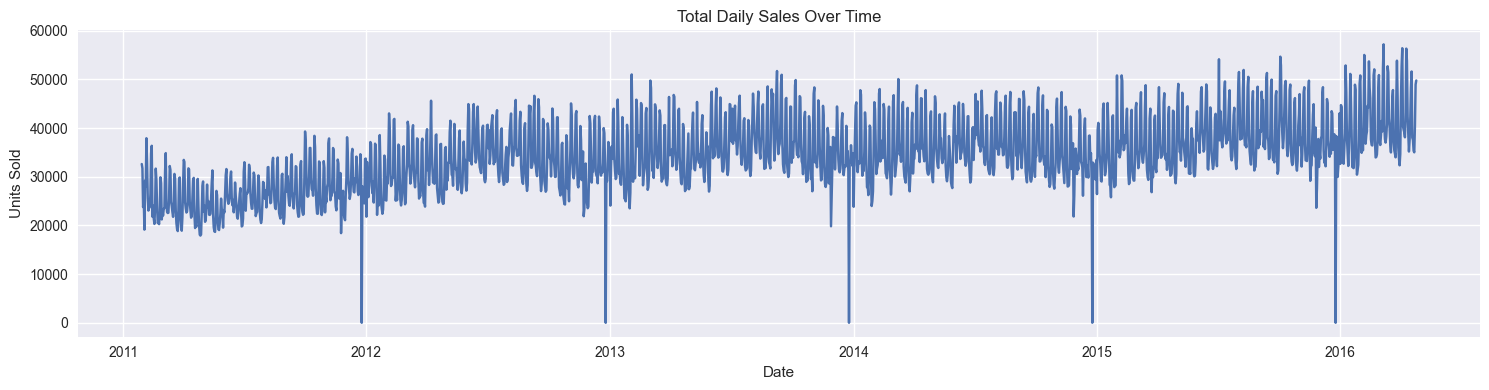

In [20]:
daily_sales = sales_long.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15,4))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig(r'D:\Naveed\Educational\retail-demand-forecasting\retail-demand-forecasting\reports\total_sales.png')
plt.show()

In [21]:
sell_prices = pd.read_csv(DATA_PATH + 'sell_prices.csv')

In [22]:
sales = pd.read_csv(DATA_PATH + 'sales_train_validation.csv')

In [23]:
print("Calendar:", calendar.shape)

Calendar: (1969, 14)


In [24]:
print("Sell prices:", sell_prices.shape)

Sell prices: (6841121, 4)


In [25]:
print("Sales:", sales.shape)

Sales: (30490, 1919)


In [26]:
sales_long.to_csv(r'D:\Naveed\Educational\retail-demand-forecasting\retail-demand-forecasting\data\processed\sales_long.csv', index=False)